# Import data

In [ ]:
import urllib.request
import zipfile

url = "http://mattmahoney.net/dc/text8.zip"
urllib.request.urlretrieve(url, "text8.zip")

with zipfile.ZipFile("text8.zip", 'r') as zip_ref:
    zip_ref.extractall()

with open("text8", "r") as f:
    raw_data = f.read()


# Preprocess data

In [ ]:
import re

def preprocess_data(data):
    data = data.lower()
    data = re.sub(r'[^a-z\s]', '', data)
    words = data.split()
    return words


In [ ]:
def create_context(data, target_index, size):
    begin = max(0, target_index - size)
    end = min(len(data), target_index + size + 1)

    context_words = np.concatenate([data[begin:target_index],
    data[target_index+1:end]])
    return context_words


def get_corpus(data, target_index, size):
    target_word = data[target_index]
    context_words = create_context(data, target_index, size)

    return target_word, context_words


def initialize_V_V_prime(vocab_size, embedding_dim):
    V = np.random.uniform(-0.05, 0.05, (vocab_size, embedding_dim))
    V_prime = np.random.uniform(-0.05, 0.05, (vocab_size, embedding_dim))
    return V, V_prime

# No batch

In [ ]:
import numpy as np


def softmax_probs(x):
    e_x = np.exp(x - np.max(x))
    return e_x / np.sum(e_x)


def forward(V, V_prime, contex_indexes):
    h = np.mean(V[contex_indexes], axis=0)
    logits = np.dot(V_prime, h)
    probs = softmax_probs(logits)
    return h, logits, probs


def log_softmax(x):
    x = x - np.max(x)
    return x - np.log(np.sum(np.exp(x)))


def cross_entropy_loss(logits, target_index):
    return -log_softmax(logits)[target_index]

def backward(probs, target_index, h, V_prime, context_size):
    def calc_gradient_logits(probs, target_index):
        grad_logits = probs.copy()
        grad_logits[target_index] -= 1
        return grad_logits

    def calc_grad_V_prime(grad_logits, h):
        return np.outer(grad_logits, h)

    def calc_grad_h(grad_logits, V_prime):
        return np.dot(V_prime.T, grad_logits)

    def calc_grad_V(grad_h, context_size):
        return grad_h / context_size

    grad_logits = calc_gradient_logits(probs, target_index)
    grad_V_prime = calc_grad_V_prime(grad_logits, h)
    grad_h = calc_grad_h(grad_logits, V_prime)
    grad_V = calc_grad_V(grad_h, context_size)

    return grad_V, grad_V_prime


def update_weights(V, V_prime, context_indices, grad_V, grad_V_prime, lr):
    V_prime -= lr * grad_V_prime
    V[context_indices] -= lr * grad_V


def train_cbow(words_indexes, vocab_size, embedding_dim=50, context_size=2,
               lr=0.05, epochs=10, seed=42):
    np.random.seed(seed)
    V, V_prime = initialize_V_V_prime(vocab_size, embedding_dim)
    losses = []

    for epoch in range(epochs):
        loss_sum = 0
        for target_index in range(len(words_indexes)):
            target_word, context_indices = get_corpus(words_indexes, target_index, context_size)
            if context_indices is None:
                continue

            h, logits, probs = forward(V, V_prime, context_indices)
            loss = cross_entropy_loss(logits, target_word)
            grad_V, grad_V_prime = backward(probs, target_word, h, V_prime, len(context_indices))
            update_weights(V, V_prime, context_indices, grad_V, grad_V_prime, lr)
            loss_sum += loss

        avg_loss = loss_sum / len(words_indexes)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} - Avg Loss: {avg_loss:.4f}")


    return V, V_prime, losses

# Batch version



In [ ]:
import numpy as np


def softmax_probs_batch(logits):
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)


def create_batches(words_indexes, context_size, batch_size):
    N = len(words_indexes)
    indices = np.arange(N)
    np.random.shuffle(indices)

    context_batch_list = []
    target_batch_list = []

    for batch_start in range(0, N, batch_size):
        batch_indices = indices[batch_start:batch_start + batch_size]
        context_batch = []
        target_batch = []

        for target_idx in batch_indices:
            context = create_context(words_indexes, target_idx, context_size)
            if context is None:
                continue
            context_batch.append(context)
            target_batch.append(words_indexes[target_idx])

        if context_batch:
            context_batch_list.append(context_batch)
            target_batch_list.append(target_batch)

    return context_batch_list, target_batch_list


def forward_pass_batch(V, V_prime, context_batch, target_batch):
    h_batch = np.array([np.mean(V[idx], axis=0) for idx in context_batch])
    logits_batch = np.dot(h_batch, V_prime.T)
    probs_batch = softmax_probs_batch(logits_batch)
    losses = -np.log(probs_batch[np.arange(len(target_batch)), target_batch] + 1e-12)
    return np.mean(losses), probs_batch, logits_batch, h_batch


def backward_pass_batch(V, V_prime, target_batch, probs_batch, h_batch, context_batch):
    B = len(target_batch)
    grad_logits = probs_batch.copy()
    grad_logits[np.arange(B), target_batch] -= 1

    grad_V_prime = np.dot(grad_logits.T, h_batch)
    grad_h_batch = np.dot(grad_logits, V_prime)

    grad_V = np.zeros_like(V)
    for i in range(B):
        for idx in context_batch[i]:
            grad_V[idx] += grad_h_batch[i] / len(context_batch[i])

    return grad_V, grad_V_prime


def update_weights_batch(V, V_prime, grad_V, grad_V_prime, lr):
    V_prime -= lr * grad_V_prime
    V -= lr * grad_V


def train_cbow_batch(words_indexes, vocab_size, embedding_dim=50, context_size=5,
                     lr=0.1, epochs=10, batch_size=32, seed=42):
    np.random.seed(seed)
    V, V_prime = initialize_V_V_prime(vocab_size, embedding_dim)
    epoch_losses = []

    for epoch in range(epochs):
        loss_sum = 0
        context_batches, target_batches = create_batches(words_indexes, context_size, batch_size)

        for context_batch, target_batch in zip(context_batches, target_batches):
            loss, probs_batch, logits_batch, h_batch = forward_pass_batch(
                V, V_prime, context_batch, target_batch
            )
            grad_V, grad_V_prime = backward_pass_batch(
                V, V_prime, target_batch, probs_batch, h_batch, context_batch
            )
            update_weights_batch(V, V_prime, grad_V, grad_V_prime, lr)
            loss_sum += loss * len(target_batch)

        epoch_losses.append(loss_sum / len(words_indexes))
        print(f"Epoch {epoch+1}/{epochs} - Avg Loss: {epoch_losses[-1]:.4f}")

    return V, V_prime, epoch_losses


words = words = raw_data.split()[:10000]
word_dict = {word: i for i, word in enumerate(set(words))}
words_indexes = np.array([word_dict[word] for word in words])
vocab_size = len(word_dict)

V, V_prime, losses = train_cbow_batch(
    words_indexes,
    vocab_size,
    embedding_dim=10,
    context_size=5,
    lr=0.1,
    epochs=10,
    batch_size=32
)

Epoch 1/10 - Avg Loss: 7.4971
Epoch 2/10 - Avg Loss: 6.7361
Epoch 3/10 - Avg Loss: 6.5589
Epoch 4/10 - Avg Loss: 6.4503
Epoch 5/10 - Avg Loss: 6.3562
Epoch 6/10 - Avg Loss: 6.2593
Epoch 7/10 - Avg Loss: 6.1564
Epoch 8/10 - Avg Loss: 6.0525
Epoch 9/10 - Avg Loss: 5.9444
Epoch 10/10 - Avg Loss: 5.8356


In [ ]:
def predict_word(context_indexes, V, V_prime, inv_word_dict):

    h, logits, probs = forward(V, V_prime, context_indexes)
    predicted_idx = np.argmax(probs)
    return inv_word_dict[predicted_idx]

In [ ]:
def predict_word_prob(context_indexes, V, V_prime, inv_word_dict):
    h, logits, probs = forward(V, V_prime, context_indexes)
    word_probs = {inv_word_dict[i]: float(probs[i]) for i in range(len(probs))}
    sorted_probs = dict(sorted(word_probs.items(), key=lambda item: item[1], reverse=True))

    return sorted_probs

#Plots

In [ ]:
!pip install adjustText

In [ ]:
import matplotlib.pyplot as plt
from adjustText import adjust_text
import seaborn as sns
import random

def plot_losses(losses):
    plt.plot(losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()


def plot_word_embeddings(V, word_dict, n=12):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 8))

    words_to_plot = random.sample(list(word_dict.items()), min(n, len(word_dict)))

    texts = []
    for word, i in words_to_plot:
        x, y = V[i]
        plt.scatter(x, y, c='royalblue', edgecolors='w', s=60, alpha=0.8)
        texts.append(plt.text(x, y, word, fontsize=10, fontweight='medium'))

    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red', lw=0.5))

    plt.title('Word Embeddings Visualization', fontsize=15, pad=20)
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.show()


def plot_word_distribution(probs_dict):
    sorted_data = dict(sorted(probs_dict.items(), key=lambda item: item[1]))
    words = list(sorted_data.keys())
    values = list(sorted_data.values())

    plt.figure(figsize=(10, 6))
    bars = plt.barh(words, values, color='skyblue')

    plt.xlabel('Probability')
    plt.title('Predicted Word Distribution')
    plt.xlim(0, 1.0)
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    for bar in bars:
        width = bar.get_width()
        if width > 0.01:
            plt.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                     f'{width:.2%}', va='center')

    plt.tight_layout()
    plt.show()


# Examples

In [ ]:
with open("text8", "r") as f:
    raw_data = f.read()

words = preprocess_data(raw_data)[:10000]
word_dict = {word: i for i, word in enumerate(set(words))}
words_indexes = np.array([word_dict[word] for word in words])
vocab_size = len(word_dict)

V, V_prime, losses = train_cbow(
    words_indexes,
    vocab_size,
    embedding_dim=50,
    context_size=5,
    lr=0.3,
    epochs=15,
)

Epoch 1/15 - Avg Loss: 6.8947
Epoch 2/15 - Avg Loss: 6.4352
Epoch 3/15 - Avg Loss: 6.1688
Epoch 4/15 - Avg Loss: 5.8528
Epoch 5/15 - Avg Loss: 5.4832
Epoch 6/15 - Avg Loss: 5.0661
Epoch 7/15 - Avg Loss: 4.6100
Epoch 8/15 - Avg Loss: 4.1242
Epoch 9/15 - Avg Loss: 3.6205
Epoch 10/15 - Avg Loss: 3.1115
Epoch 11/15 - Avg Loss: 2.6125
Epoch 12/15 - Avg Loss: 2.1404
Epoch 13/15 - Avg Loss: 1.7104
Epoch 14/15 - Avg Loss: 1.3335
Epoch 15/15 - Avg Loss: 1.0179


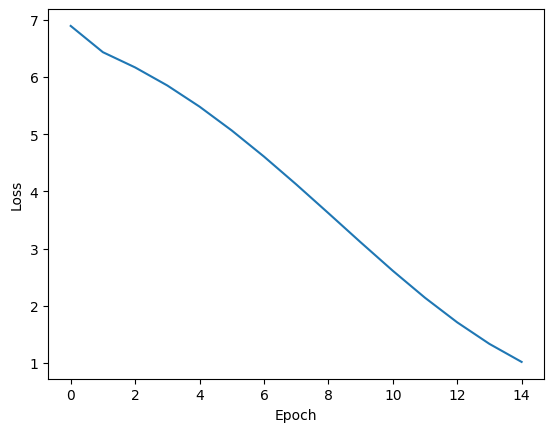

In [ ]:
plot_losses(losses)

Epoch 1/50 - Avg Loss: 2.3024
Epoch 2/50 - Avg Loss: 2.3022
Epoch 3/50 - Avg Loss: 2.3019
Epoch 4/50 - Avg Loss: 2.3015
Epoch 5/50 - Avg Loss: 2.3007
Epoch 6/50 - Avg Loss: 2.2994
Epoch 7/50 - Avg Loss: 2.2972
Epoch 8/50 - Avg Loss: 2.2933
Epoch 9/50 - Avg Loss: 2.2862
Epoch 10/50 - Avg Loss: 2.2731
Epoch 11/50 - Avg Loss: 2.2490
Epoch 12/50 - Avg Loss: 2.2048
Epoch 13/50 - Avg Loss: 2.1272
Epoch 14/50 - Avg Loss: 2.0034
Epoch 15/50 - Avg Loss: 1.8383
Epoch 16/50 - Avg Loss: 1.6678
Epoch 17/50 - Avg Loss: 1.5232
Epoch 18/50 - Avg Loss: 1.4035
Epoch 19/50 - Avg Loss: 1.3007
Epoch 20/50 - Avg Loss: 1.2099
Epoch 21/50 - Avg Loss: 1.1302
Epoch 22/50 - Avg Loss: 1.0623
Epoch 23/50 - Avg Loss: 1.0051
Epoch 24/50 - Avg Loss: 0.9558
Epoch 25/50 - Avg Loss: 0.9119
Epoch 26/50 - Avg Loss: 0.8717
Epoch 27/50 - Avg Loss: 0.8343
Epoch 28/50 - Avg Loss: 0.7991
Epoch 29/50 - Avg Loss: 0.7656
Epoch 30/50 - Avg Loss: 0.7338
Epoch 31/50 - Avg Loss: 0.7031
Epoch 32/50 - Avg Loss: 0.6735
Epoch 33/50 - Avg

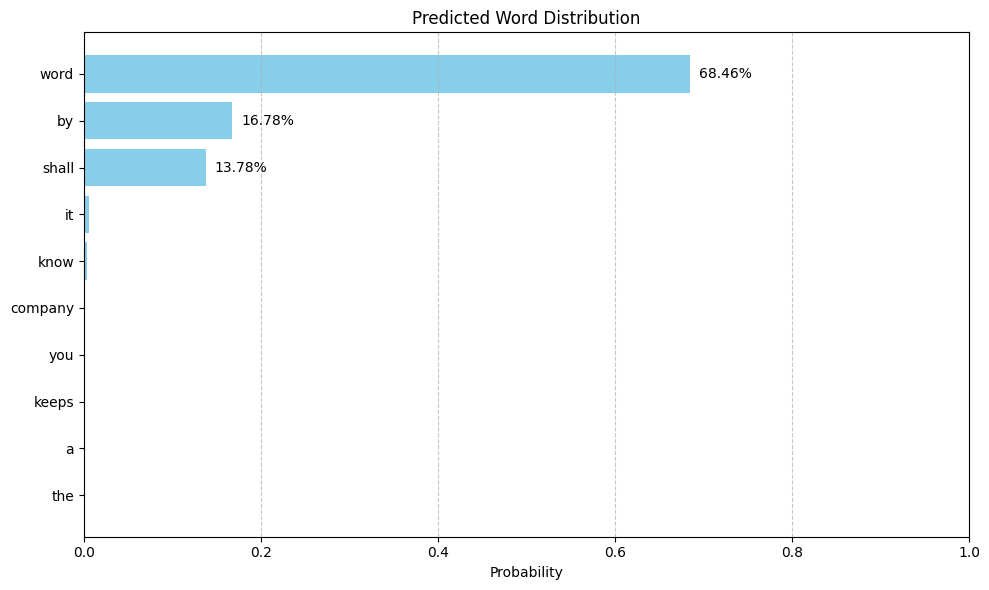

In [ ]:
raw_data = "You shall know a word by the company it keeps"
words = preprocess_data(raw_data)

word_dict = {word: i for i, word in enumerate(sorted(set(words)))}
inv_word_dict = {i: word for word, i in word_dict.items()}
words_indexes = np.array([word_dict[word] for word in words])
vocab_size = len(word_dict)



V, V_prime, losses = train_cbow_batch(
    words_indexes,
    vocab_size,
    embedding_dim=2,
    context_size=2,
    lr=0.5,
    epochs=50
)

# " know a word by the"
words_indexes = np.array([word_dict[word] for word in ['know', 'a', 'by', 'the']])

predict_word(words_indexes, V, V_prime, inv_word_dict)
probs = predict_word_prob(words_indexes, V, V_prime, inv_word_dict)
plot_word_distribution(probs)

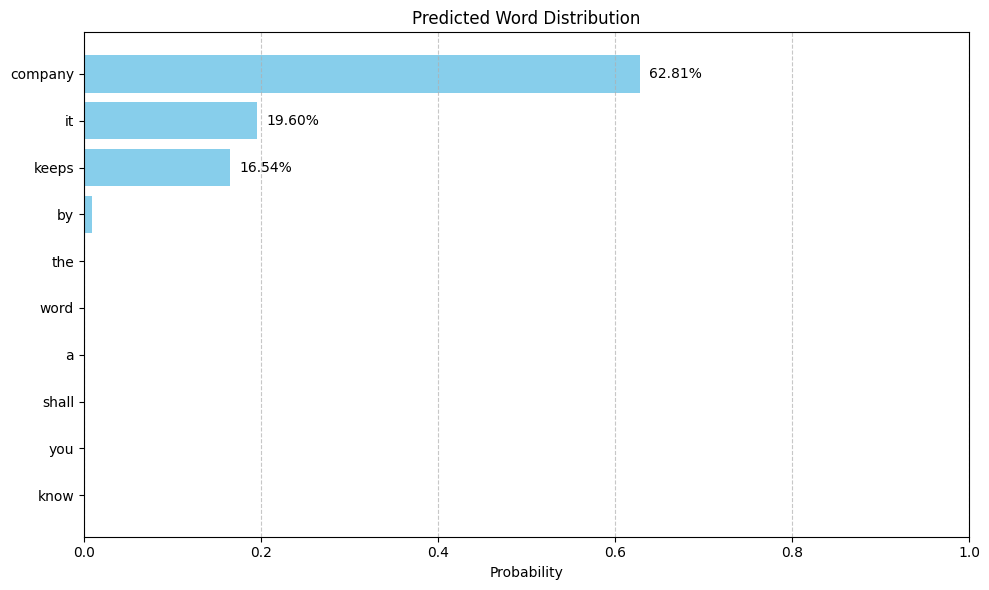

In [ ]:
# "by the company it keeps"
words_indexes = np.array([word_dict[word] for word in ['by', 'the', 'it', 'keeps']])

predict_word(words_indexes, V, V_prime, inv_word_dict)
probs = predict_word_prob(words_indexes, V, V_prime, inv_word_dict)
plot_word_distribution(probs)

In [ ]:
with open("text8", "r") as f:
    raw_data = f.read()

words = words = preprocess_data(raw_data)[:20000]
word_dict = {word: i for i, word in enumerate(set(words))}
words_indexes = np.array([word_dict[word] for word in words])
vocab_size = len(word_dict)

V, V_prime, losses = train_cbow_batch(
    words_indexes,
    vocab_size,
    embedding_dim=2,
    context_size=5,
    lr=0.3,
    epochs=15,
    batch_size=32
)

Epoch 1/15 - Avg Loss: 7.1396
Epoch 2/15 - Avg Loss: 6.7128
Epoch 3/15 - Avg Loss: 6.5946
Epoch 4/15 - Avg Loss: 6.5195
Epoch 5/15 - Avg Loss: 6.4710
Epoch 6/15 - Avg Loss: 6.4318
Epoch 7/15 - Avg Loss: 6.4064
Epoch 8/15 - Avg Loss: 6.3727
Epoch 9/15 - Avg Loss: 6.3515
Epoch 10/15 - Avg Loss: 6.3403
Epoch 11/15 - Avg Loss: 6.3230
Epoch 12/15 - Avg Loss: 6.3060
Epoch 13/15 - Avg Loss: 6.2985
Epoch 14/15 - Avg Loss: 6.2835
Epoch 15/15 - Avg Loss: 6.2742


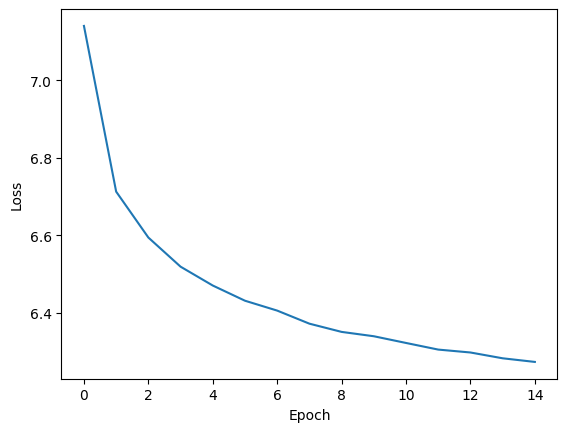

In [ ]:
plot_losses(losses)

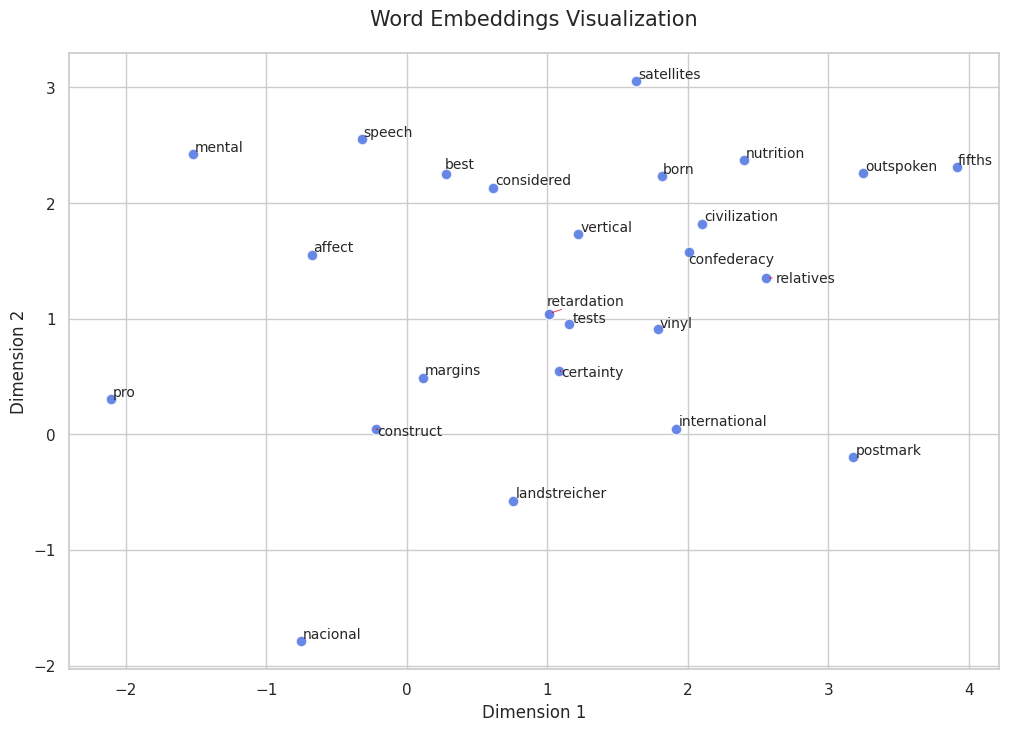

In [ ]:
plot_word_embeddings(V, word_dict, n=25)


# Some Tests

In [ ]:
def test_get_corpus():
  raw_data = "You shall know a word by the company it keeps"
  data = np.array(raw_data.split())
  target_word, context_words = get_corpus(data, 4, 2)
  assert target_word == 'word'
  assert np.array_equal(context_words, ['know', 'a', 'by', 'the'])

def test_get_corpus_begin():
  raw_data = "You shall know a word by the company it keeps"
  data = np.array(raw_data.split())
  target_word, context_words = get_corpus(data, 1, 2)
  assert np.array_equal(context_words, ['You' ,'know', 'a'])

def test_get_corpus_end():
  raw_data = "You shall know a word by the company it keeps"
  data = np.array(raw_data.split())
  target_word, context_words = get_corpus(data, 7, 5)
  assert np.array_equal(context_words, ['know', 'a', 'word' ,'by', 'the', 'it' ,'keeps'])

In [ ]:
def test_softmax_is_close():
  data = np.array([1, 2, 3])
  probs = softmax_probs(data)
  assert np.isclose(np.sum(probs), 1.0)

def test_softmax_mon():
  data = np.array([1, 2, 3])
  probs = softmax_probs(data)
  assert probs[0] < probs[2], probs[3]

def test_softmax_nan():
  data = np.array([1e4, 1e6, 1e8])
  probs = softmax_probs(data)
  assert not np.any(np.isnan(probs))


In [ ]:
test_softmax_nan()
test_softmax_mon()
test_softmax_is_close()
test_get_corpus()
test_get_corpus_begin()
test_get_corpus_end()